In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'   # 맑은 고딕
mpl.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지


In [1]:
# 파이토치 라이브러리 가져오기
import torch
import numpy as np

In [2]:
# 0계 텐서(스칼라)
r0 = torch.tensor(1.0).float()

# type 확인
print(type(r0))

# dtype 확인
print(r0.dtype)

<class 'torch.Tensor'>
torch.float32


In [3]:
# 1계 텐서(벡터)

# 1계 넘파이 변수 작성
r1_np = np.array([1, 2, 3, 4, 5])
print(r1_np.shape)

# 넘파이에서 텐서로 변환
r1 = torch.tensor(r1_np).float()

# dtype 확인
print(r1.dtype)

# shape 확인
print(r1.shape)

# 데이터 확인
print(r1.data)

(5,)
torch.float32
torch.Size([5])
tensor([1., 2., 3., 4., 5.])


In [4]:
# 2계 텐서(행렬)

# 2계 넘파이 변수 작성
r2_np = np.array([[1, 5, 6], [4, 3, 2]])
print(r2_np.shape)

# 넘파이에서 텐서로 변환
r2 = torch.tensor(r2_np).float()

# shape 확인
print(r2.shape)

# 데이터 확인
print(r2.data)

(2, 3)
torch.Size([2, 3])
tensor([[1., 5., 6.],
        [4., 3., 2.]])


In [5]:
# ３계 텐서

# 난수 seed 초기화
torch.manual_seed(123)

# shape=[3,2,2]의 정규분포 텐서 작성
r3 = torch.randn((3, 2, 2))

# shape 확인
print(r3.shape)

# 데이터 확인
print(r3.data)

torch.Size([3, 2, 2])
tensor([[[-0.1115,  0.1204],
         [-0.3696, -0.2404]],

        [[-1.1969,  0.2093],
         [-0.9724, -0.7550]],

        [[ 0.3239, -0.1085],
         [ 0.2103, -0.3908]]])


In [6]:
# 4계 텐서

# 요소가 모두 1인 shape=[2,3,2,2] 텐서 작성
r4 = torch.ones((2, 3, 2, 2))

# shape 확인
print(r4.shape)

# 데이터 확인
print(r4.data)

torch.Size([2, 3, 2, 2])
tensor([[[[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]]],


        [[[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]]]])


In [7]:
#
# view 함수
#
# 2계화
# 남은 자리에 -1을 지정하면 이 수를 자동으로 조정함

r6 = r3.view(3, -1)

# shape 확인
print(r6.shape)

# 값 확인
print(r6.data)

torch.Size([3, 4])
tensor([[-0.1115,  0.1204, -0.3696, -0.2404],
        [-1.1969,  0.2093, -0.9724, -0.7550],
        [ 0.3239, -0.1085,  0.2103, -0.3908]])


In [8]:
# 1계화
# 남은 자리에 -1을 지정하면 이 수를 자동으로 조정함

r7 = r3.view(-1)

# shape 확인
print(r7.shape)

# 값 확인
print(r7.data)

torch.Size([12])
tensor([-0.1115,  0.1204, -0.3696, -0.2404, -1.1969,  0.2093, -0.9724, -0.7550,
         0.3239, -0.1085,  0.2103, -0.3908])


In [ ]:
#
# 그 밖의 속성
#

# requires_grad 속성
print('requires_grad: ', r1.requires_grad) 

# device 속성
print('device: ', r1.device)

requires_grad:  False
device:  cpu


In [ ]:
#
# iterm 함수
#

# 스칼라 텐서(0계 텐서)는 item 함수로 값을 꺼낼 수 있음

print(r0)
item = r0.item()

print(type(item))
print(item)

# item 함수는 0계 텐서에서만 사용할 수 있음 -> 엥? 뭔 소리인지 모르겟음
# item 함수는 x가 뭐 하나 어쩌구..


tensor(1.)
<class 'float'>
1.0


In [11]:
# 스칼라 이외의 텐서에 item 함수는 무효함

print(r1.item())

RuntimeError: a Tensor with 5 elements cannot be converted to Scalar

In [16]:
# 예외 사항: 
# 요소 수가 하나뿐인 1계 텐서는 OK
# (2계 이상에서도 마찬가지)
t1 = torch.ones(1)

# shape 확인
print(t1.shape)

# item 함수 호출
print(t1.item())

torch.Size([1])
1.0


In [17]:
#
# max 함수
#
# 텐서 r2 확인
print(r2)

# max 함수를 인수 없이 호출하면, 최댓값을 얻음
print(r2.max())

tensor([[1., 5., 6.],
        [4., 3., 2.]])
tensor(6.)


In [18]:
# torch.max 함수
# 두번째 인수는 기준이 되는 축을 의미함
print(torch.max(r2, 1))

torch.return_types.max(
values=tensor([6., 4.]),
indices=tensor([2, 0]))


In [19]:
# 몇 번째 요소가 최댓값인지 indices 확인을 통해 알 수 있음
# 아래 계산은 다중 분류에서 예측 라벨을 구할 때 자주 사용되는 패턴임
print(torch.max(r2, 1)[1])

tensor([2, 0])


In [ ]:
#
# 넘파이 변수로 변환
#

#print(r2.data)
#print(type(r2.data))
# 넘파이로 변환 방법
# r2_np = r2.data.numpy()  # 미묘한 차이는 나중에 이해하기 바랍니다.

r2_np = r2.numpy()
# 이거 r2는 텐서인데, r2_np는 넘파이 배열이 되는 거임.

# type 확인
print(type(r2_np))

# 값 확인
print(r2_np)

<class 'numpy.ndarray'>
[[1. 5. 6.]
 [4. 3. 2.]]


# 2주차는 여기까지

파이토치는 거대한 미분기계이다..!

여기까지 타이핑해서 결과 ch02_김연성에 실행결과 복사하기

In [32]:

# 2.4 2차 함수의 경사 계산

In [30]:
# x를 넘파이 배열로 정의
x_np = np.arange(-2, 2.1, 0.25)

# x값 표시
print(x_np)

[-2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.  ]


In [33]:
# (1) 경사 계산용 변수 정의

x = torch.tensor(x_np, requires_grad=True, 
    dtype=torch.float32)

# 결과 확인
print(x)

tensor([-2.0000, -1.7500, -1.5000, -1.2500, -1.0000, -0.7500, -0.5000, -0.2500,
         0.0000,  0.2500,  0.5000,  0.7500,  1.0000,  1.2500,  1.5000,  1.7500,
         2.0000], requires_grad=True)


In [37]:
# 2차 함수의 계산 : 계산 그래프는 내부에서 자동 생성됨

y = 2 * x**2 + 2

# y의 계산 결과 확인

print(y)

tensor([10.0000,  8.1250,  6.5000,  5.1250,  4.0000,  3.1250,  2.5000,  2.1250,
         2.0000,  2.1250,  2.5000,  3.1250,  4.0000,  5.1250,  6.5000,  8.1250,
        10.0000], grad_fn=<AddBackward0>)


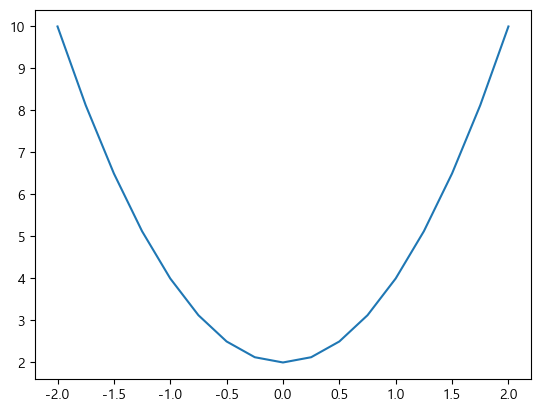

In [39]:
# 그래프 출력

plt.plot(x.data, y.data)
plt.show()

In [40]:
# 경사 계산을 위해 최종 값은 스칼라일 필요가 있으므로, 더미로 sum 함수를 붙임

z = y.sum()

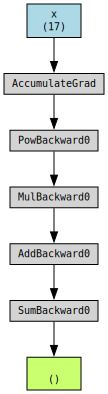

In [ ]:
# (3) 계산 그래프 시각화

# 설치: pip install torchviz
# 필요한 라이브러리 임포트
from torchviz import make_dot

# 시각화 함수 호출
g= make_dot(z, params={'x': x})
display(g)

In [42]:
# (4) 경사 계산

z.backward()

In [45]:
# (5) 경삿값 가져오기

print(x.grad)

# 질문: 출력 값이 정확한가? 이유는?

tensor([-8., -7., -6., -5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.,
         6.,  7.,  8.])


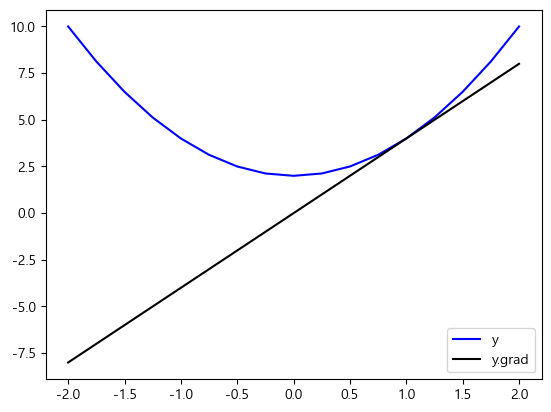

In [44]:
# 원래 함수와 경사 그래프

plt.plot(x.data, y.data, c='b', label='y')
plt.plot(x.data, x.grad.data, c='k', label='y.grad')
plt.legend()
plt.show()

In [46]:
# 경삿값 초기화의 필요성 예시
# 경사를 초기화하지 않고 두번째 경사를 계산

y = 2 * x**2 + 2
z = y.sum()
z.backward()

# x의 경사 확인
print(x.grad)

tensor([-16., -14., -12., -10.,  -8.,  -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,
          8.,  10.,  12.,  14.,  16.])


이 경삿값은 경사 계산의 값이 점차 합해진 결과다. 새로운 값을 계산하기 위해서 경삿값을 조기화 해야한다.

In [47]:
# (6) 경삿값의 초기화는 zero_() 함수를 사용함

x.grad.zero_()
print(x.grad)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


#### 2.5 시그모이드 함수의 경사 계산

시그모이드 함수는 수식으로 나타내면 다음과 같지만, 여기서는 파이토치에서 제공하는 함수를 사용한다.

$ y = \dfrac{1}{1 + \exp{(-x)}} $

In [ ]:
# (1) 시그모이드 함수의 정의

sigmoid = torch.nn.Sigmoid()

In [51]:
# (2) y값의 계산

y = sigmoid(x)   # x는 앞의 x와 동일한 텐서임

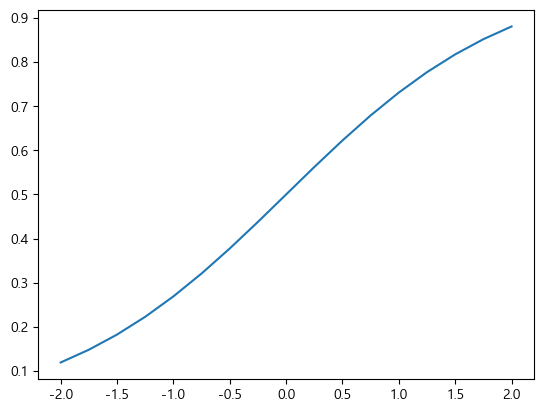

In [52]:
# 그래프 출력

plt.plot(x.data, y.data)
plt.show()

In [53]:
# 경사 계산을 위해 최종 값은 스칼라일 필요가 있으므로, 더미로 sum 함수를 붙임

z = y.sum()

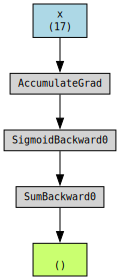

In [54]:
# (3) 계산 그래프 시각화

g = make_dot(z, params={'x': x})
display(g)

In [55]:
# (4) 경사 계산
z.backward()

# (5) 경삿값 확인
print(x.grad)

tensor([0.1050, 0.1261, 0.1491, 0.1731, 0.1966, 0.2179, 0.2350, 0.2461, 0.2500,
        0.2461, 0.2350, 0.2179, 0.1966, 0.1731, 0.1491, 0.1261, 0.1050])


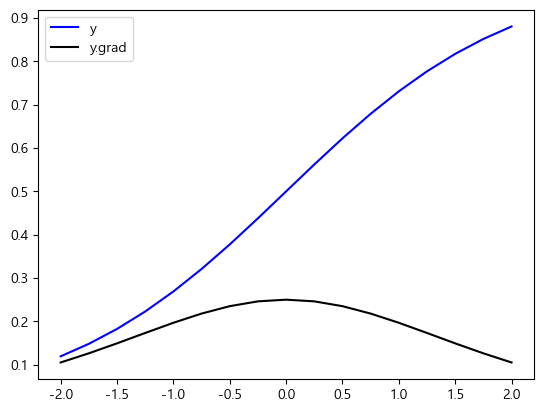

In [56]:
# 원래 함수와 경사 그래프

plt.plot(x.data, y.data, c='b', label='y')
plt.plot(x.data, x.grad.data, c='k', label='y.grad')
plt.legend()
plt.show()

In [57]:
# (6) 경사 초기화는 zero_() 함수를 사용

x.grad.zero_()
print(x.grad)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


부록: 아래 코드는 무시해도 괜찮음.

(참고) 시그모이드 함수를 직접 구현한 경우

In [58]:
# 시그모이드 함수의 정의

def sigmoid(x):
    return(1/(1 + torch.exp(-x)))

In [59]:
# (2) y값의 계산

y = sigmoid(x)

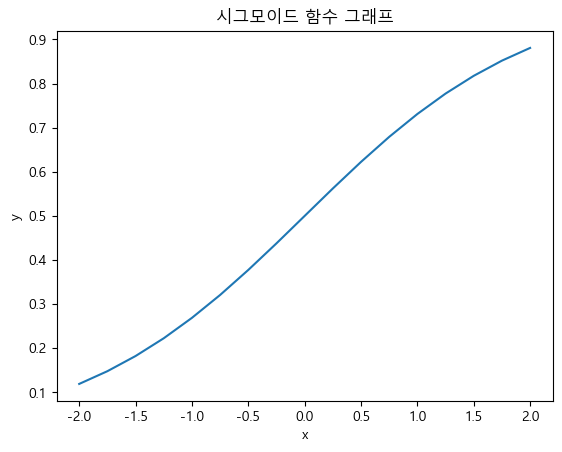

In [60]:
# 그래프 출력

plt.plot(x.data, y.data)
plt.xlabel('x')
plt.ylabel('y')
plt.title('시그모이드 함수 그래프')
plt.show()

In [61]:
# 경사 계산을 위해 최종 값은 스칼라일 필요가 있으므로, 더미로 sum 함수를 붙임

z = y.sum()

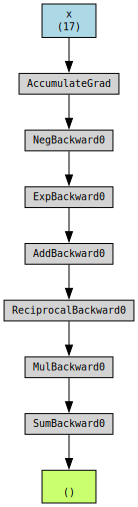

In [62]:
# (3) 계산 그래프 시각화

params = {'x': x}
g = make_dot(z, params=params)
display(g)

In [63]:
# (4) 경사 계산
z.backward()

# (5) 경삿값 확인
print(x.grad)

tensor([0.1050, 0.1261, 0.1491, 0.1731, 0.1966, 0.2179, 0.2350, 0.2461, 0.2500,
        0.2461, 0.2350, 0.2179, 0.1966, 0.1731, 0.1491, 0.1261, 0.1050])


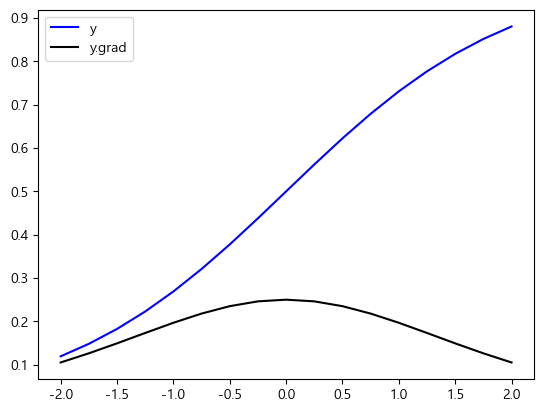

In [64]:
# 원래 함수와 경사 그래프

plt.plot(x.data, y.data, c='b', label='y')
plt.plot(x.data, x.grad.data, c='k', label='y.grad')
plt.legend()
plt.show()